## Instalação e Imports

In [ ]:
!pip install pandas numpy matplotlib seaborn kagglehub -q

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Estilo visual ──
plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#2d3248',
    'axes.labelcolor'  : '#c9d1e0',
    'xtick.color'      : '#8892a4',
    'ytick.color'      : '#8892a4',
    'text.color'       : '#c9d1e0',
    'grid.color'       : '#2d3248',
    'grid.linewidth'   : 0.5,
    'font.family'      : 'monospace',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'figure.dpi'       : 110,
})

CORES   = ['#4fc3f7', '#ef5350']   # Azul = sem diabetes | Vermelho = com diabetes
ACCENT  = '#4fc3f7'
SEED    = 42
np.random.seed(SEED)

print('✅ Imports OK')

✅ Imports OK


## Carregamento dos Dados

O dataset possui **3 arquivos CSV**. Usarei o arquivo principal com todos os 253.680 registros e o target binário original (desbalanceado), que reflete a realidade da população.

In [ ]:
# Opção 1: download via kagglehub
# Requer: kaggle.json configurado em ~/.kaggle/kaggle.json
# Gere sua API key em: https://www.kaggle.com/settings → API → Create New Token

try:
    import kagglehub
    path = kagglehub.dataset_download('alexteboul/diabetes-health-indicators-dataset')
    import os
    csv_path = os.path.join(path, 'diabetes_binary_health_indicators_BRFSS2015.csv')
    df = pd.read_csv(csv_path)
    print(f'✅ Dataset carregado via kagglehub: {df.shape}')

except Exception as e:
    print(f'⚠️  kagglehub falhou ({e})')
    print('   → Fazendo download direto via URL pública...')

    # Opção 2: URL pública de fallback
    URL = (
        'https://raw.githubusercontent.com/dsaks/cdc-diabetes-health-indicators/'
        'main/diabetes_binary_health_indicators_BRFSS2015.csv'
    )
    df = pd.read_csv(URL)
    print(f'✅ Dataset carregado via URL: {df.shape}')

Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
✅ Dataset carregado via kagglehub: (253680, 22)


In [ ]:
# Dicionário completo das features
DICIONARIO = {
    'Diabetes_binary'      : 'TARGET — 0: sem diabetes | 1: com diabetes',
    'HighBP'               : 'Pressão arterial alta diagnosticada (0/1)',
    'HighChol'             : 'Colesterol alto diagnosticado (0/1)',
    'CholCheck'            : 'Checou colesterol nos últimos 5 anos (0/1)',
    'BMI'                  : 'Índice de Massa Corporal (contínuo)',
    'Smoker'               : 'Fumou ≥100 cigarros na vida (0/1)',
    'Stroke'               : 'Já teve AVC (0/1)',
    'HeartDiseaseorAttack' : 'Doença coronária ou infarto (0/1)',
    'PhysActivity'         : 'Atividade física nos últimos 30 dias (0/1)',
    'Fruits'               : 'Consome frutas ≥1x/dia (0/1)',
    'Veggies'              : 'Consome vegetais ≥1x/dia (0/1)',
    'HvyAlcoholConsump'    : 'Consumo pesado de álcool (0/1)',
    'AnyHealthcare'        : 'Tem plano de saúde (0/1)',
    'NoDocbcCost'          : 'Não foi ao médico por custo (0/1)',
    'GenHlth'              : 'Saúde geral autorrelatada (1=excelente → 5=ruim)',
    'MentHlth'             : 'Dias de saúde mental ruim (últimos 30 dias, 0–30)',
    'PhysHlth'             : 'Dias de saúde física ruim (últimos 30 dias, 0–30)',
    'DiffWalk'             : 'Dificuldade para caminhar/subir escadas (0/1)',
    'Sex'                  : 'Sexo (0=Feminino | 1=Masculino)',
    'Age'                  : 'Faixa etária (1=18–24 até 13=80+)',
    'Education'            : 'Nível de escolaridade (1=Nunca estudou → 6=Graduação)',
    'Income'               : 'Faixa de renda anual (1=<$10k → 8=>$75k)',
}

print('📋 Dicionário de dados:')
for col, desc in DICIONARIO.items():
    print(f'  {col:<25} → {desc}')

📋 Dicionário de dados:
  Diabetes_binary           → TARGET — 0: sem diabetes | 1: com diabetes
  HighBP                    → Pressão arterial alta diagnosticada (0/1)
  HighChol                  → Colesterol alto diagnosticado (0/1)
  CholCheck                 → Checou colesterol nos últimos 5 anos (0/1)
  BMI                       → Índice de Massa Corporal (contínuo)
  Smoker                    → Fumou ≥100 cigarros na vida (0/1)
  Stroke                    → Já teve AVC (0/1)
  HeartDiseaseorAttack      → Doença coronária ou infarto (0/1)
  PhysActivity              → Atividade física nos últimos 30 dias (0/1)
  Fruits                    → Consome frutas ≥1x/dia (0/1)
  Veggies                   → Consome vegetais ≥1x/dia (0/1)
  HvyAlcoholConsump         → Consumo pesado de álcool (0/1)
  AnyHealthcare             → Tem plano de saúde (0/1)
  NoDocbcCost               → Não foi ao médico por custo (0/1)
  GenHlth                   → Saúde geral autorrelatada (1=excelente → 5=ruim)

In [ ]:
# Visualizando as primeiras linhas
print(f'Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas\n')
df.head(8)

Shape: 253,680 linhas × 22 colunas



,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0


##  Qualidade dos Dados

In [ ]:
# Resumo geral de qualidade
resumo = pd.DataFrame({
    'Tipo'          : df.dtypes,
    'Nulos'         : df.isnull().sum(),
    'Nulos (%)'     : (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos'        : df.nunique(),
    'Min'           : df.min(),
    'Max'           : df.max(),
    'Média'         : df.mean().round(2),
})

print('=' * 70)
print('RESUMO DE QUALIDADE DOS DADOS')
print('=' * 70)
resumo

RESUMO DE QUALIDADE DOS DADOS


,Tipo,Nulos,Nulos (%),Únicos,Min,Max,Média
Diabetes_binary,float64,0,0.0,2,0.0,1.0,0.14
HighBP,float64,0,0.0,2,0.0,1.0,0.43
HighChol,float64,0,0.0,2,0.0,1.0,0.42
CholCheck,float64,0,0.0,2,0.0,1.0,0.96
BMI,float64,0,0.0,84,12.0,98.0,28.38
Smoker,float64,0,0.0,2,0.0,1.0,0.44
Stroke,float64,0,0.0,2,0.0,1.0,0.04
HeartDiseaseorAttack,float64,0,0.0,2,0.0,1.0,0.09
PhysActivity,float64,0,0.0,2,0.0,1.0,0.76
Fruits,float64,0,0.0,2,0.0,1.0,0.63


O dataset apresenta qualidade excepcional: nenhum valor ausente nas 253.680 observações e todas as variáveis binárias com codificação consistente (apenas 0 e 1). A variável-alvo revela um desbalanceamento significativo de aproximadamente 6:1, com apenas 14% dos pacientes diagnosticados com diabetes, o que inviabiliza o uso isolado da acurácia como métrica de avaliação. O perfil médio da amostra, IMC de 28,4 (sobrepeso), faixa etária predominante de 55–59 anos, alta cobertura de saúde (95%) e renda/escolaridade acima da média, sugere um viés de seleção típico de surveys telefônicas, com sub-representação de populações mais vulneráveis. Destaca-se a alta prevalência de hipertensão (43%) e colesterol elevado (42%), ambos fatores de risco conhecidos para diabetes. O valor máximo de IMC igual a 98 configura um outlier extremo que deverá ser investigado no pré-processamento. Por fim, variáveis como HvyAlcoholConsump (6%) e Stroke (4%) apresentam prevalência muito baixa, o que pode limitar seu poder preditivo individual nos modelos.

In [ ]:
# Verificação de duplicatas
n_dup = df.duplicated().sum()
pct_dup = n_dup / len(df) * 100

print(f'Linhas duplicadas: {n_dup:,} ({pct_dup:.2f}%)')

if n_dup > 0:
    print('\n⚠️  Exemplo de duplicatas:')
    print(df[df.duplicated(keep=False)].head(4))
else:
    print('✅ Nenhuma duplicata encontrada.')

# Verificação de valores fora do esperado
print('\n📌 Valores únicos por feature binária (devem ser apenas 0 e 1):')
binarias = ['HighBP','HighChol','CholCheck','Smoker','Stroke',
            'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
            'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex']
for col in binarias:
    vals = sorted(df[col].unique().tolist())
    status = '✅' if vals == [0.0, 1.0] or vals == [0, 1] else '⚠️'
    print(f'  {status} {col:<25}: {vals}')

Linhas duplicadas: 24,206 (9.54%)

⚠️  Exemplo de duplicatas:
    Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
5               0.0     1.0       1.0        1.0  25.0     1.0     0.0   
25              0.0     0.0       0.0        1.0  32.0     0.0     0.0   
29              0.0     0.0       1.0        1.0  31.0     1.0     0.0   
44              0.0     0.0       1.0        1.0  31.0     1.0     0.0   

    HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
5                    0.0           1.0     1.0  ...            1.0   
25                   0.0           1.0     1.0  ...            1.0   
29                   0.0           1.0     1.0  ...            1.0   
44                   0.0           0.0     1.0  ...            1.0   

    NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
5           0.0      2.0       0.0       2.0       0.0  1.0  10.0        6.0   
25          0.0      2.0       0.0       0.0       0.0  

Foram identificadas 24.206 duplicatas (9,54% do dataset), exigindo remoção para evitar viés e overfitting.
Essas duplicatas possuem valores idênticos nas 21 features, indicando provável coincidência de respostas, não erro de ingestão.
Ainda assim, optou-se por removê-las como medida conservadora.
As 14 variáveis binárias foram validadas, contendo apenas valores 0 e 1, sem inconsistências.
Não foram encontrados nulos mascarados ou codificações incorretas.
Após a limpeza, o dataset será reduzido de 253.680 para cerca de 229.474 registros.
O volume final permanece suficiente para treino e avaliação robusta dos modelos.

## Análise do Target — Desbalanceamento

Distribuição do Target:
  Sem diabetes (0): 218,334 pacientes (86.1%)
  Com diabetes (1):  35,346 pacientes (13.9%)
  Razão de desbalanceamento: 6.2:1


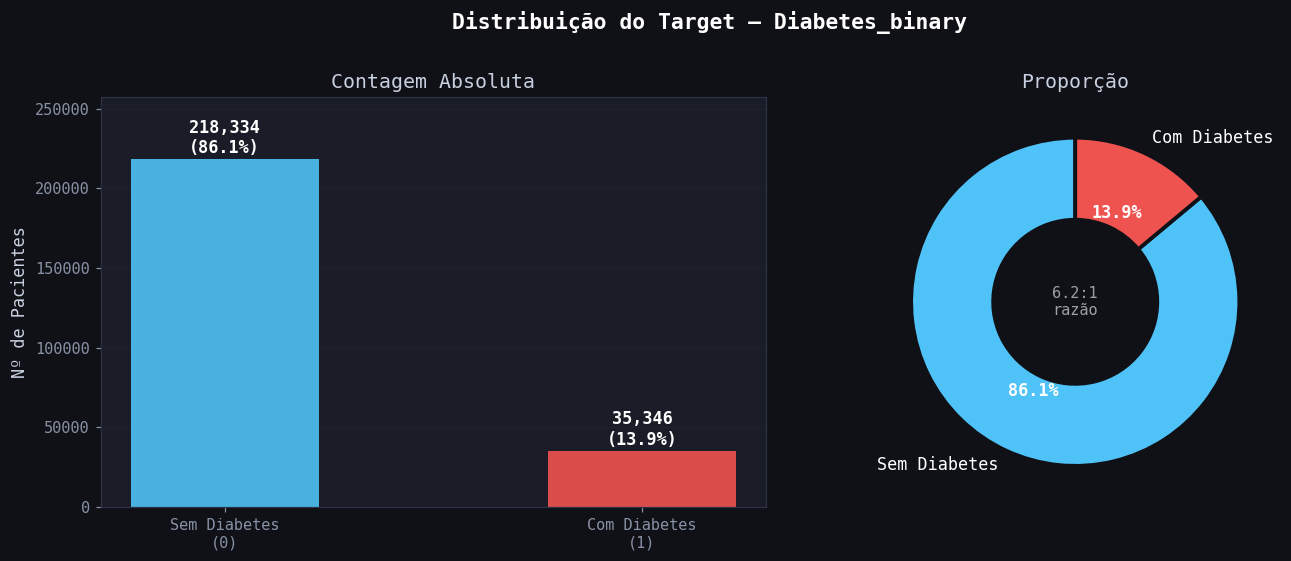


⚠️  Insight: Desbalanceamento expressivo (~86/14).
   Isso implica que um modelo que chuta "0" sempre teria 86% de acurácia.
   → Acurácia não será nossa métrica principal. Priorizaremos ROC-AUC e Recall.


In [ ]:
contagem = df['Diabetes_binary'].value_counts()
pct      = df['Diabetes_binary'].value_counts(normalize=True) * 100

print('Distribuição do Target:')
print(f'  Sem diabetes (0): {contagem[0]:>7,} pacientes ({pct[0]:.1f}%)')
print(f'  Com diabetes (1): {contagem[1]:>7,} pacientes ({pct[1]:.1f}%)')
print(f'  Razão de desbalanceamento: {contagem[0]/contagem[1]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribuição do Target — Diabetes_binary', fontsize=14,
             fontweight='bold', color='white', y=1.01)

# Barras
rotulos = ['Sem Diabetes\n(0)', 'Com Diabetes\n(1)']
bars = axes[0].bar(rotulos, contagem, color=CORES, width=0.45, edgecolor='none', alpha=0.9)
for bar, v, p in zip(bars, contagem, pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1200,
                 f'{v:,}\n({p:.1f}%)', ha='center', va='bottom',
                 fontweight='bold', color='white', fontsize=11)
axes[0].set_ylabel('Nº de Pacientes')
axes[0].set_title('Contagem Absoluta')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_axisbelow(True)
axes[0].set_ylim(0, contagem.max() * 1.18)

# Donut
wedges, texts, autos = axes[1].pie(
    contagem, labels=['Sem Diabetes', 'Com Diabetes'],
    autopct='%1.1f%%', colors=CORES, startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='#0f1117', linewidth=2.5),
    textprops={'color': 'white', 'fontsize': 11}
)
for a in autos:
    a.set_fontweight('bold')
axes[1].set_title('Proporção')
axes[1].text(0, 0, f'{contagem[0]/contagem[1]:.1f}:1\nrazão', ha='center',
             va='center', fontsize=10, color='white', alpha=0.6)

plt.tight_layout()
plt.show()

print('\n⚠️  Insight: Desbalanceamento expressivo (~86/14).')
print('   Isso implica que um modelo que chuta "0" sempre teria 86% de acurácia.')
print('   → Acurácia não será nossa métrica principal. Priorizaremos ROC-AUC e Recall.')

A variável-alvo apresenta forte desbalanceamento (6,2:1), com 86,1% sem diabetes e 13,9% positivos.
Isso torna a acurácia inadequada, pois um modelo trivial já alcançaria ~86% sem aprendizado real.
No contexto clínico, falsos negativos são mais críticos que falsos positivos.
Por isso, métricas como Recall da classe positiva e ROC-AUC são priorizadas.
Para tratar o desbalanceamento, podem ser testadas técnicas como SMOTE e ajuste de pesos de classe.
A distribuição original será mantida no conjunto de teste para garantir avaliação realista.

## Distribuição das Features Binárias

As features binárias representam condições autorrelatadas. Para cada uma, analisamos a **taxa de prevalência na população** e a **proporção de diabéticos dentro de cada grupo**.

In [ ]:
# Taxa de diabetes por feature binária
binarias_analise = [
    'HighBP','HighChol','CholCheck','Smoker','Stroke',
    'HeartDiseaseorAttack','PhysActivity','Fruits','Veggies',
    'HvyAlcoholConsump','AnyHealthcare','NoDocbcCost','DiffWalk','Sex'
]

# Taxa de diabetes por grupo (0 e 1) de cada feature
resultados_bin = []
for col in binarias_analise:
    taxa_0 = df[df[col]==0]['Diabetes_binary'].mean() * 100
    taxa_1 = df[df[col]==1]['Diabetes_binary'].mean() * 100
    prev   = df[col].mean() * 100
    resultados_bin.append({
        'Feature'     : col,
        'Taxa DM (=0)': round(taxa_0, 1),
        'Taxa DM (=1)': round(taxa_1, 1),
        'Diferença'   : round(abs(taxa_1 - taxa_0), 1),
        'Prevalência (%)': round(prev, 1),
    })

df_bin = pd.DataFrame(resultados_bin).sort_values('Diferença', ascending=False)
print('Taxa de Diabetes (%) por grupo de cada feature binária:')
print('(Ordenado por maior diferença entre os grupos)')
df_bin

Taxa de Diabetes (%) por grupo de cada feature binária:
(Ordenado por maior diferença entre os grupos)


,Feature,Taxa DM (=0),Taxa DM (=1),Diferença,Prevalência (%)
5,HeartDiseaseorAttack,12.0,33.0,21.0,9.4
12,DiffWalk,10.5,30.7,20.2,16.8
4,Stroke,13.2,31.8,18.6,4.1
0,HighBP,6.0,24.4,18.4,42.9
1,HighChol,8.0,22.0,14.0,42.4
2,CholCheck,2.5,14.4,11.8,96.3
6,PhysActivity,21.1,11.6,9.5,75.7
9,HvyAlcoholConsump,14.4,5.8,8.6,5.6
8,Veggies,18.0,13.0,5.0,81.1
3,Smoker,12.1,16.3,4.2,44.3


A análise das variáveis binárias mostra clara hierarquia de poder discriminativo para diabetes.
HeartDiseaseorAttack lidera, com diferença de 21 pp entre grupos, seguido por DiffWalk (20,2 pp) e Stroke (18,6 pp), indicando forte relação com complicações vasculares.
HighBP e HighChol também se destacam, reforçando a tríade metabólica.
A inatividade física surge como importante fator de risco, enquanto atividade física atua como proteção relevante.
HvyAlcoholConsump apresenta relação inversa, possivelmente influenciada por perfil demográfico.
Já variáveis como Sex, Fruits, AnyHealthcare e Veggies têm baixo poder isolado (<5 pp).
Ainda assim, podem agregar valor quando combinadas em modelos preditivos.

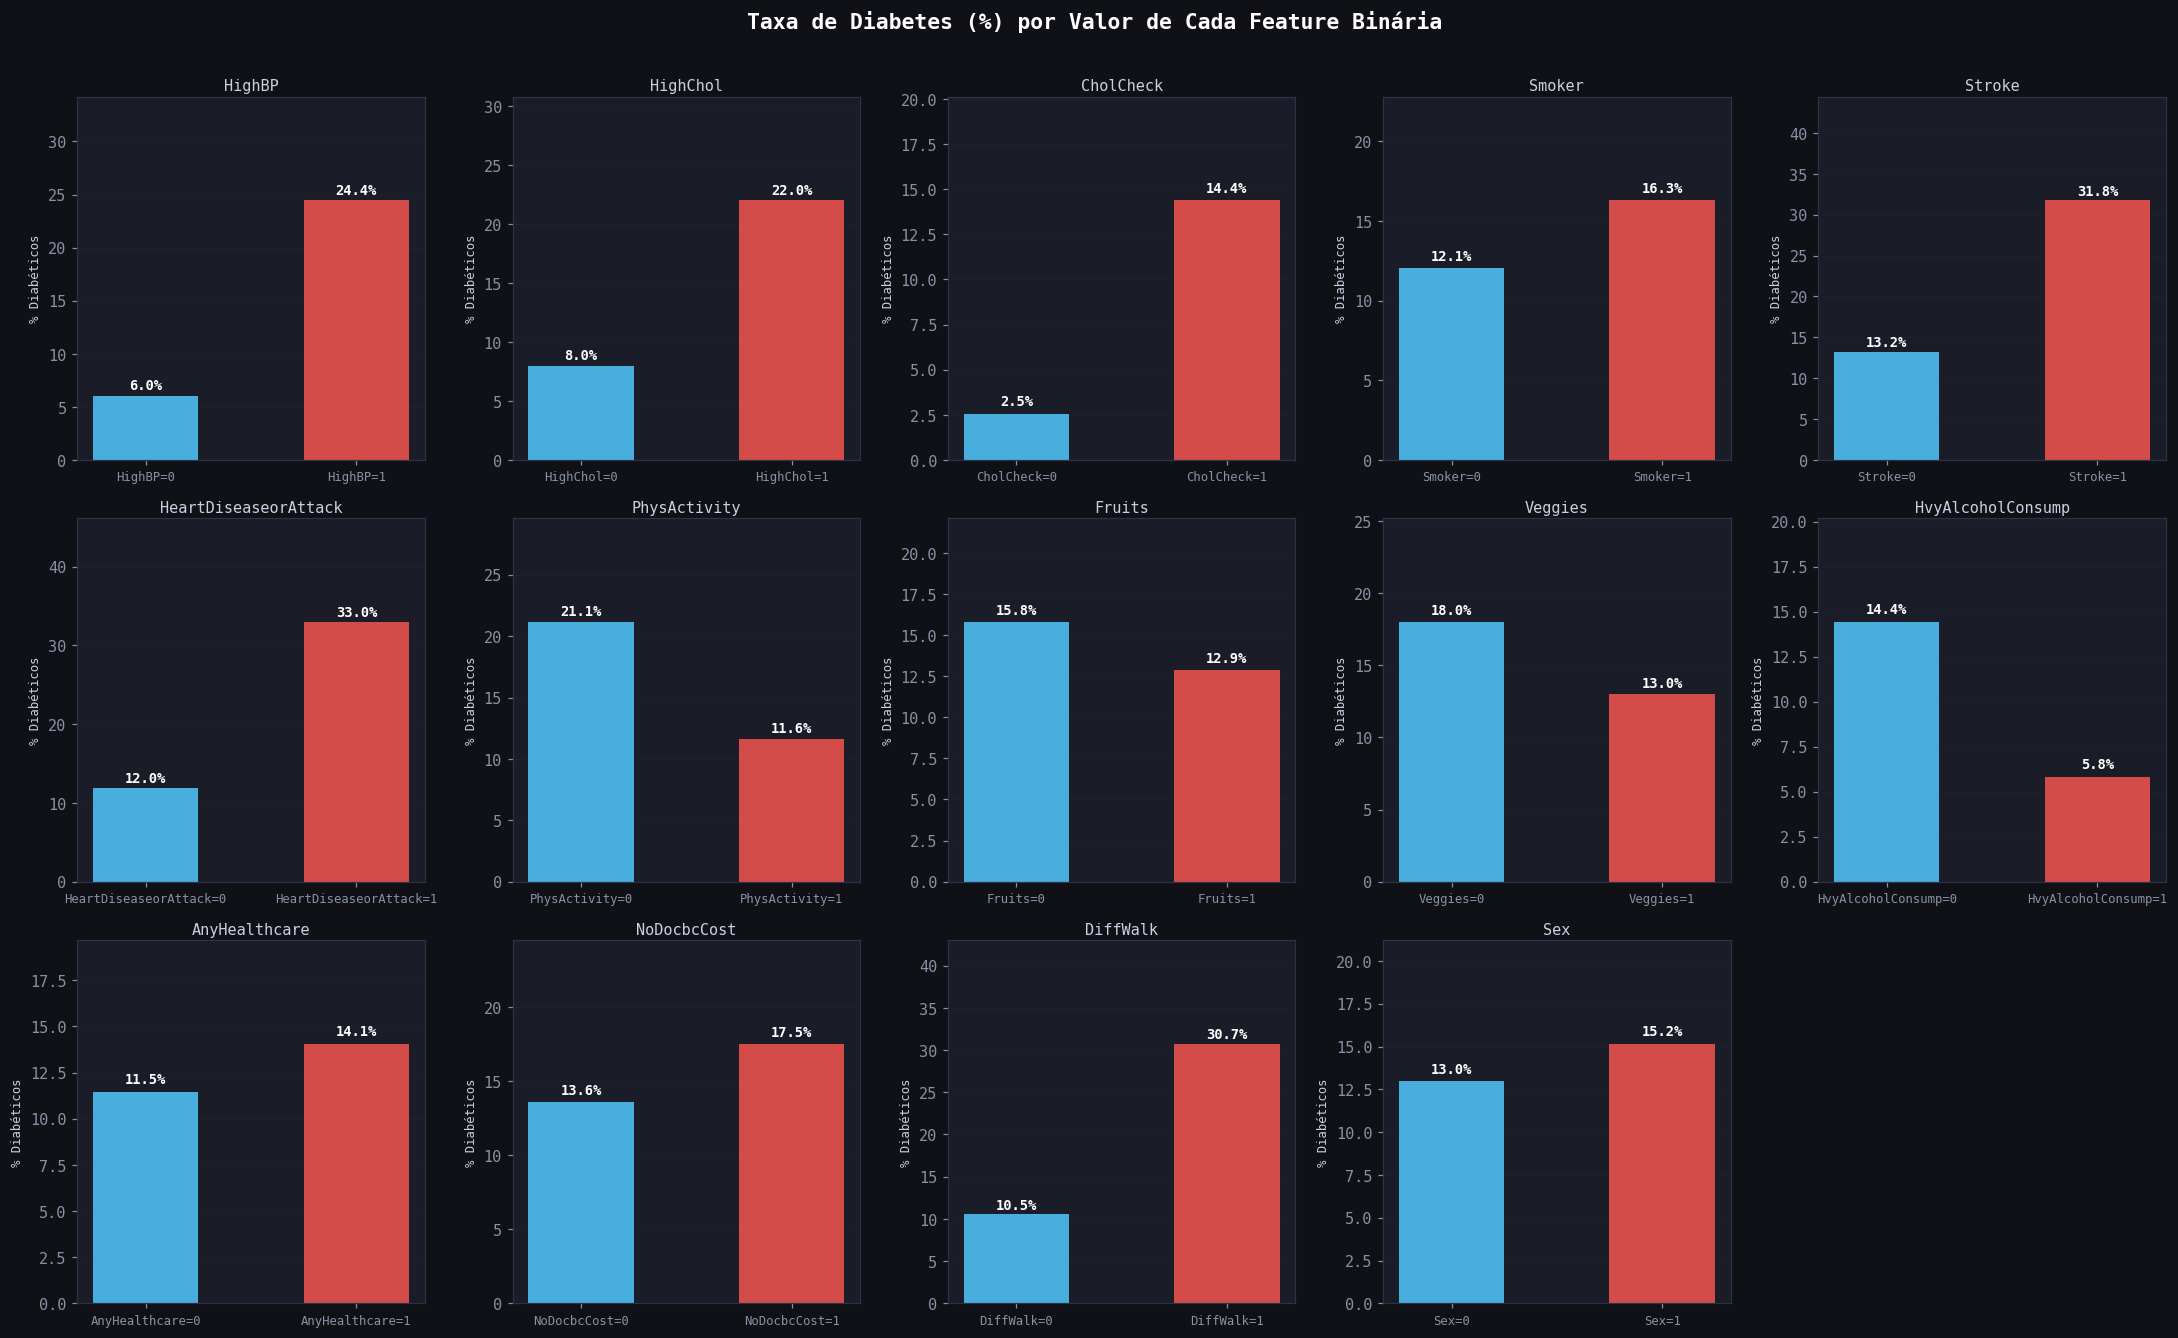

In [ ]:
# Gráfico: taxa de diabetes por feature binária
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Taxa de Diabetes (%) por Valor de Cada Feature Binária',
             fontsize=14, fontweight='bold', color='white', y=1.01)

for ax, col in zip(axes.flatten(), binarias_analise):
    taxas = df.groupby(col)['Diabetes_binary'].mean() * 100
    bars  = ax.bar([f'{col}=0', f'{col}=1'], taxas,
                   color=CORES, width=0.5, edgecolor='none', alpha=0.88)
    for bar, v in zip(bars, taxas):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=9,
                fontweight='bold', color='white')
    ax.set_title(col, fontsize=10, pad=4)
    ax.set_ylabel('% Diabéticos', fontsize=8)
    ax.set_ylim(0, min(taxas.max() * 1.4, 100))
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', labelsize=8)

# Remover eixo extra
axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.show()

Os gráficos confirmam a hierarquia de risco observada anteriormente.
PhysActivity e HvyAlcoholConsump se destacam pela inversão de padrão, indicando efeito protetor e relação contraintuitiva, respectivamente.
CholCheck reflete viés de diagnóstico: quem monitora a saúde tem maior taxa de diabetes, sem implicar causalidade.
DiffWalk e HeartDiseaseorAttack mantêm as maiores diferenças entre grupos, reforçando alto poder preditivo.
Já AnyHealthcare e Sex apresentam diferenças mínimas, com baixo poder discriminativo isolado.
Essas variáveis podem ter menor relevância ou peso reduzido na modelagem.

## Distribuição das Features Contínuas/Ordinais

BMI, GenHlth, MentHlth, PhysHlth, Age, Education e Income são variáveis com mais de 2 valores únicos.

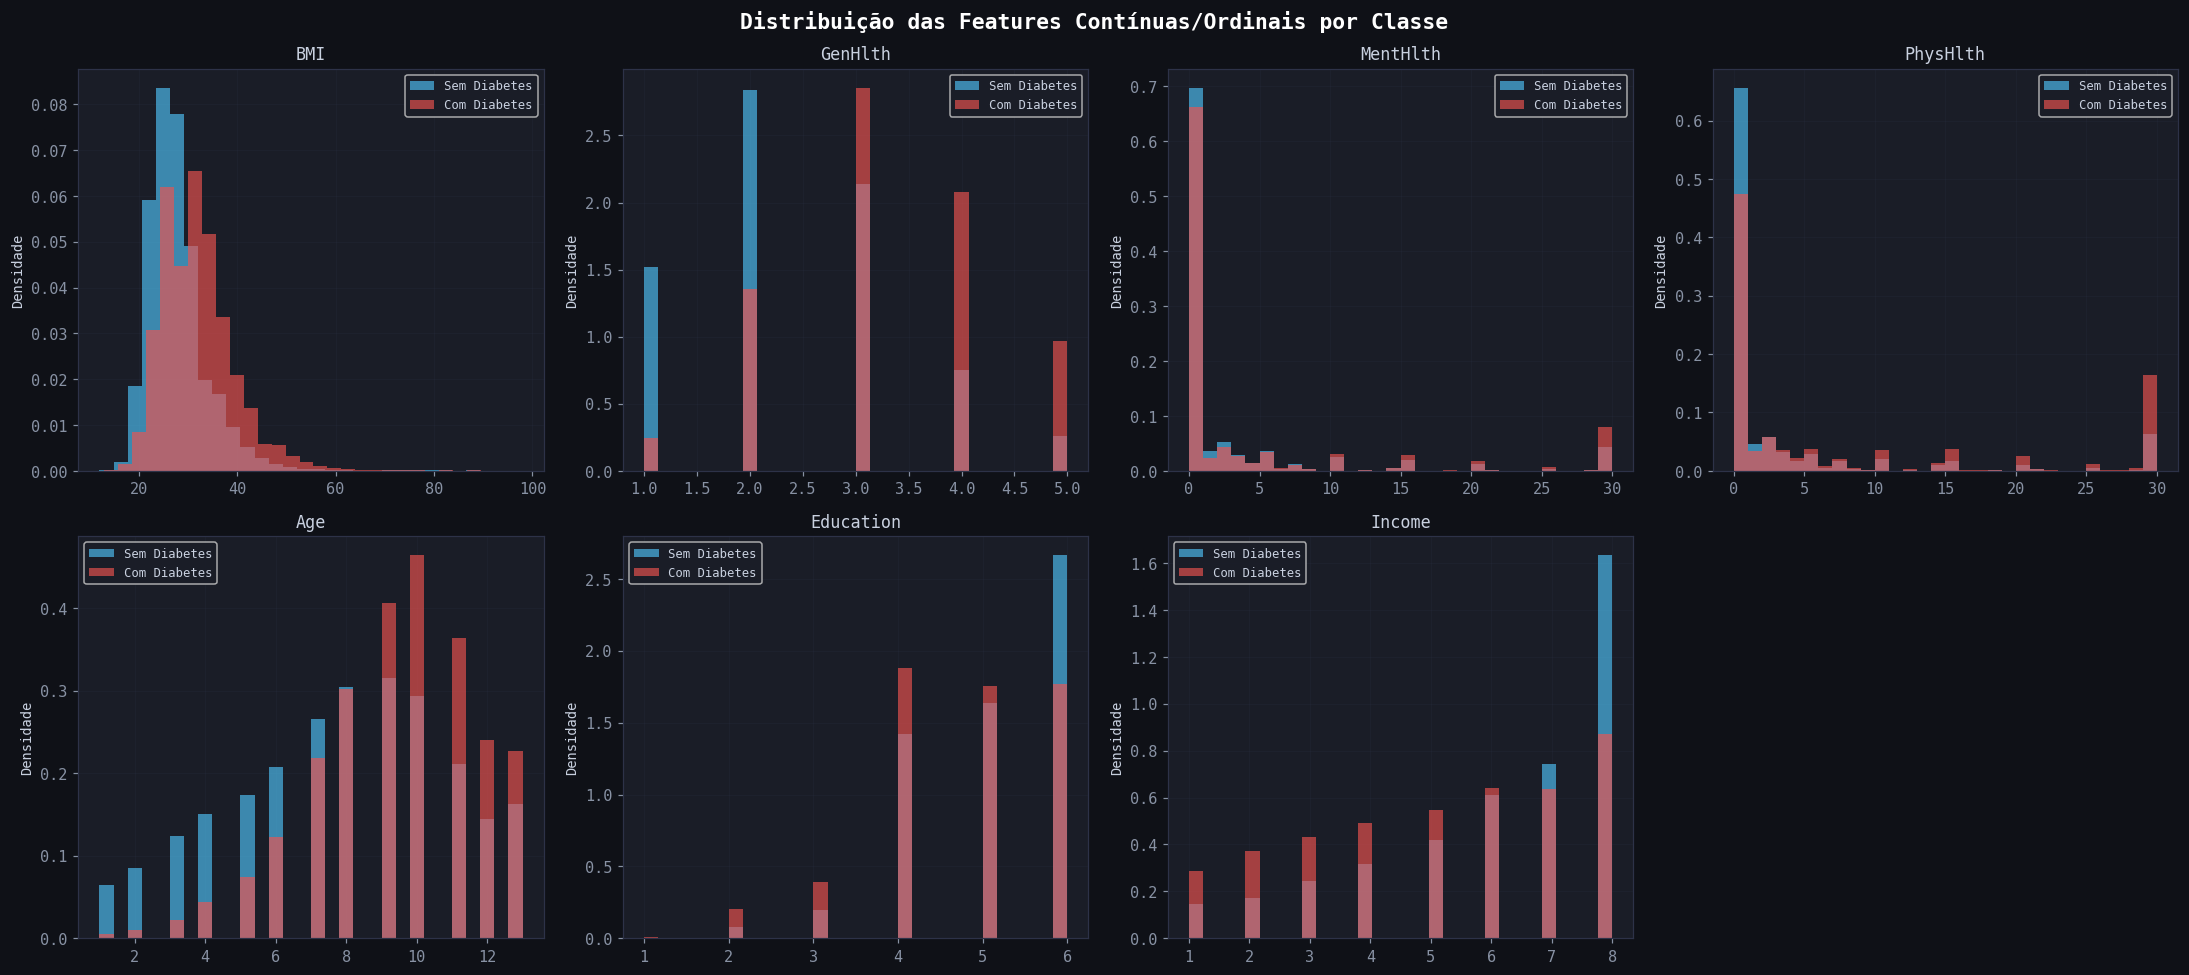

In [ ]:
continuas = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Distribuição das Features Contínuas/Ordinais por Classe',
             fontsize=14, fontweight='bold', color='white')

for ax, col in zip(axes.flatten(), continuas):
    for label, cor in zip([0, 1], CORES):
        subset = df[df['Diabetes_binary'] == label][col]
        ax.hist(subset, bins=30, alpha=0.65, color=cor, density=True,
                edgecolor='none',
                label='Sem Diabetes' if label == 0 else 'Com Diabetes')
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_ylabel('Densidade', fontsize=9)

axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.show()

BMI apresenta forte separação, com diabéticos concentrados em valores mais altos possuindo alto poder preditivo.
GenHlth também se destaca, com diabéticos em piores níveis de saúde e não diabéticos nos melhores.
MentHlth e PhysHlth têm baixa separação, indicando menor relevância isolada.
Age mostra aumento claro do risco com a idade, com inversão entre jovens e idosos.
Education apresenta separação moderada, sugerindo influência socioeconômica.
Income exibe padrão nítido: maior diabetes em rendas baixas e menor em rendas altas.
No geral, BMI, GenHlth, Age e Income são as variáveis mais informativas.

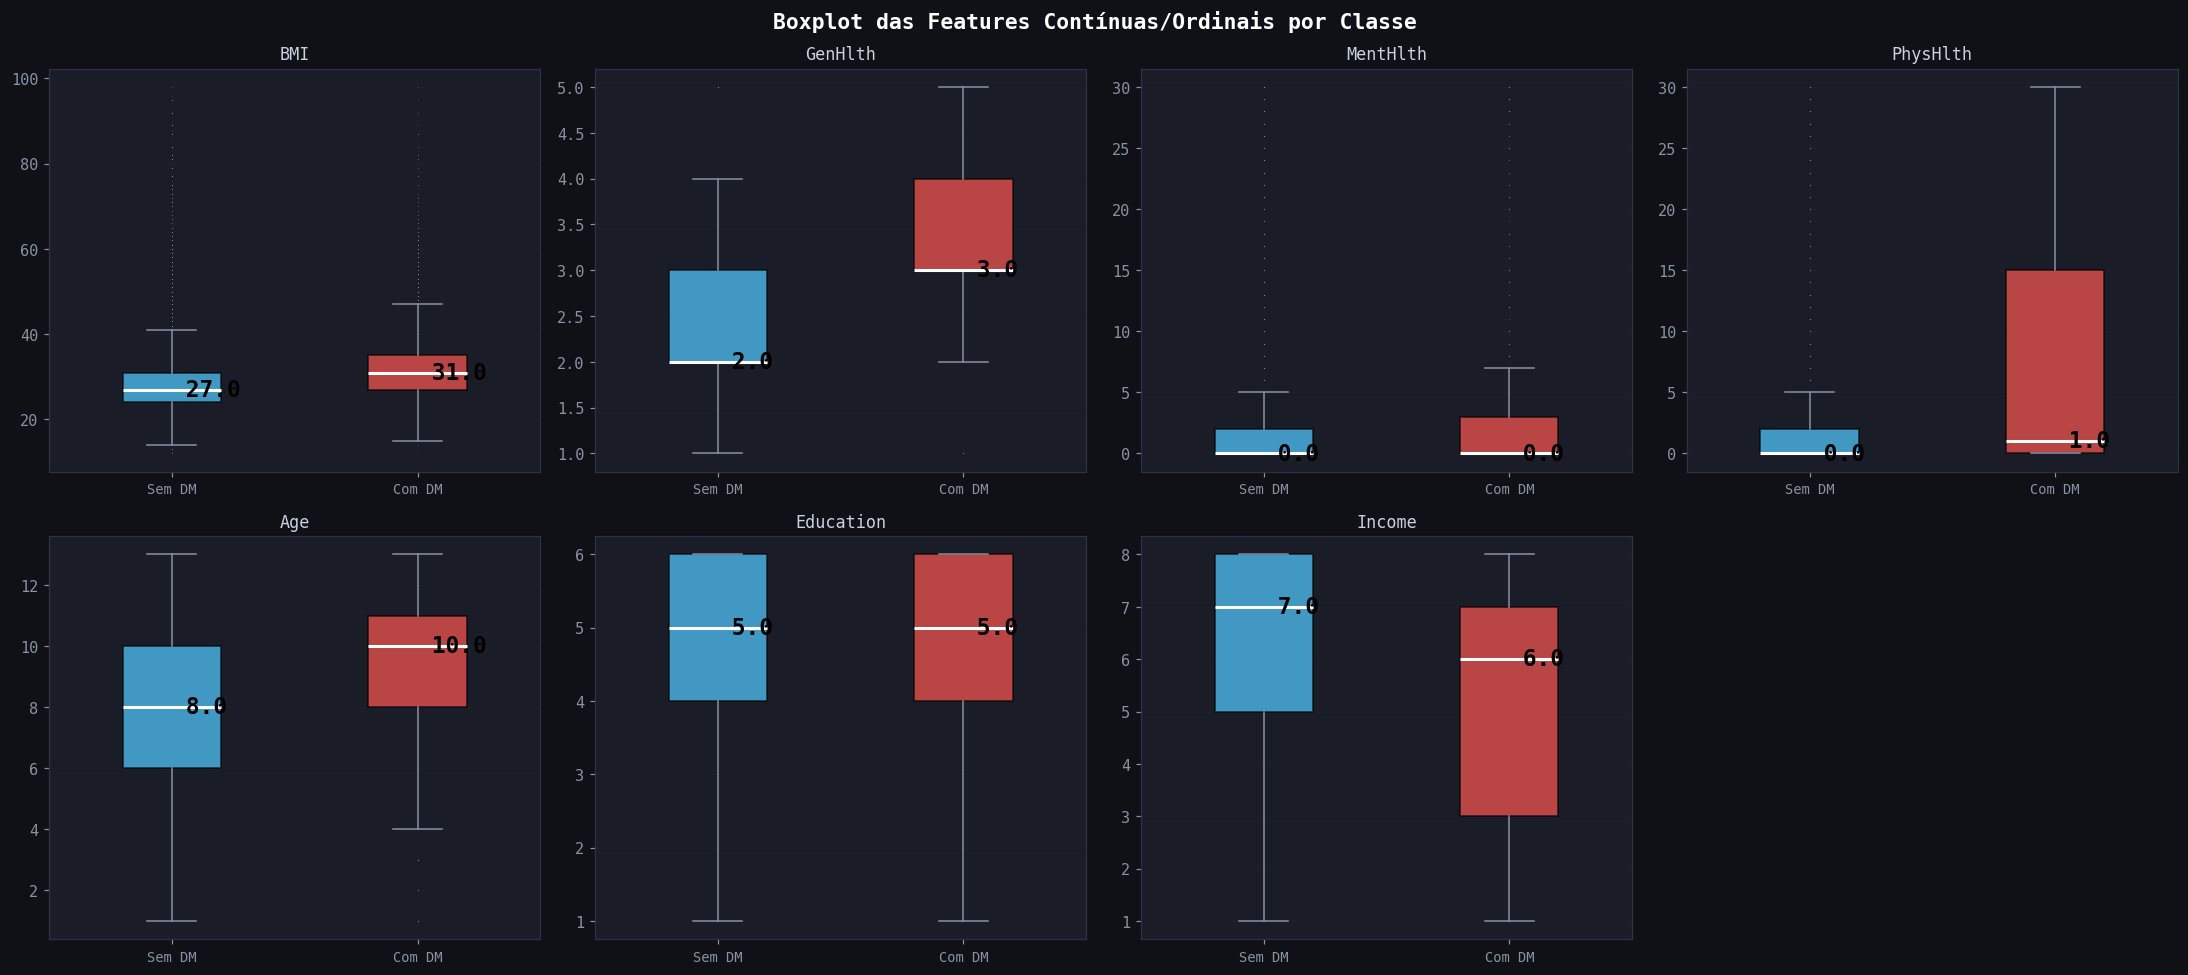

In [ ]:
# Boxplot das features contínuas por classe
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Boxplot das Features Contínuas/Ordinais por Classe',
             fontsize=14, fontweight='bold', color='white')

for ax, col in zip(axes.flatten(), continuas):
    data = [df[df['Diabetes_binary']==0][col], df[df['Diabetes_binary']==1][col]]
    bp = ax.boxplot(data, patch_artist=True, widths=0.4,
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='.', markersize=1, alpha=0.3))
    for patch, cor in zip(bp['boxes'], CORES):
        patch.set_facecolor(cor)
        patch.set_alpha(0.75)
    for whisker in bp['whiskers']:
        whisker.set_color('#8892a4')
    for cap in bp['caps']:
        cap.set_color('#8892a4')
    for flier in bp['fliers']:
        flier.set(markerfacecolor='#8892a4', markeredgecolor='none')
    ax.set_xticklabels(['Sem DM', 'Com DM'], fontsize=9)
    ax.set_title(col, fontsize=11)
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)

    # Mediana anotada
    for i, d in enumerate(data):
        med = d.median()
        ax.text(i + 1, med, f' {med:.1f}', va='center', fontsize=15,
                color='black', fontweight='bold')

axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.show()

BMI mostra diferença relevante (27 vs 31), com deslocamento claro para valores mais altos em diabéticos.
GenHlth é altamente discriminativo, com caixas quase sem sobreposição entre os grupos.
MentHlth e PhysHlth têm mediana zero e baixa separação, com diferenças apenas nas caudas.
Age indica maior concentração de diabéticos em faixas etárias mais avançadas.
Education apresenta forte sobreposição, confirmando baixo poder isolado.
Income revela renda menor e maior variabilidade entre diabéticos.
No geral, GenHlth, BMI, Age e Income se destacam como mais informativas.

## Análise de Correlação

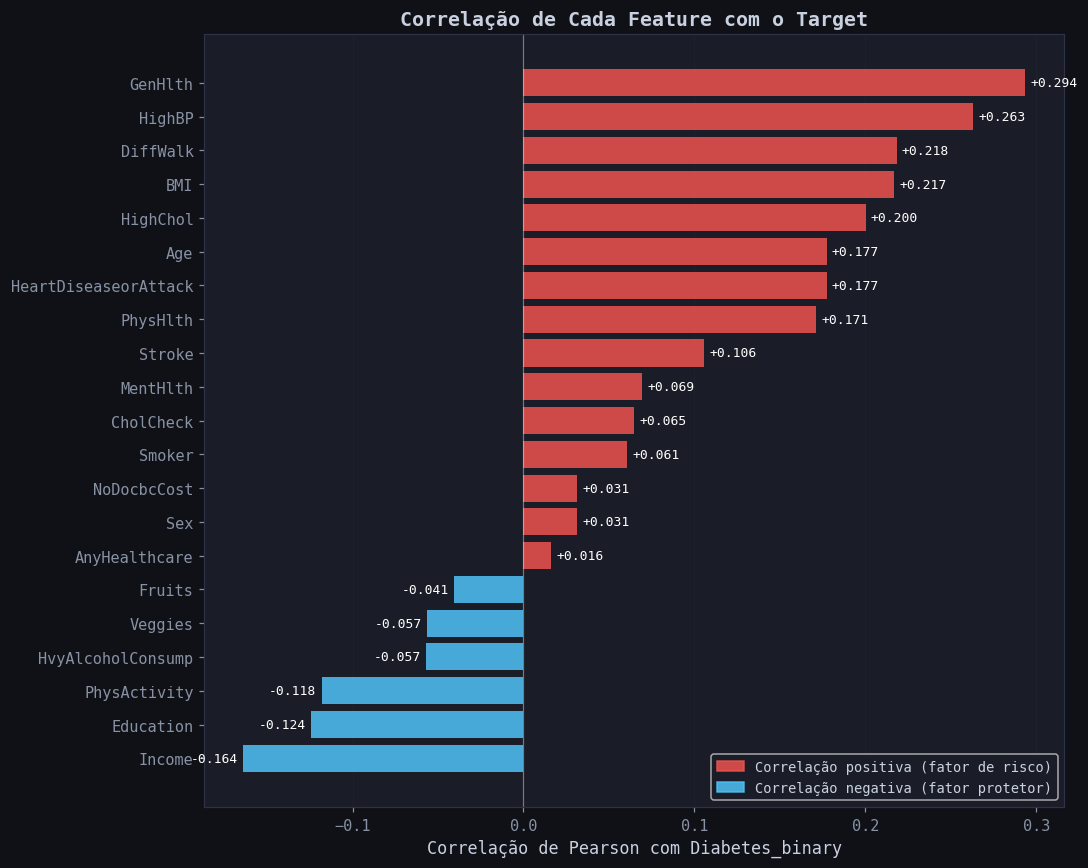


🔑 Top 5 fatores de RISCO (correlação positiva):
GenHlth     0.293569
HighBP      0.263129
DiffWalk    0.218344
BMI         0.216843
HighChol    0.200276

🛡️  Top 5 fatores PROTETORES (correlação negativa):
Income              -0.163919
Education           -0.124456
PhysActivity        -0.118133
HvyAlcoholConsump   -0.057056
Veggies             -0.056584


In [ ]:
# Correlação com o target (Point-Biserial / Pearson)
corr_target = df.corr()['Diabetes_binary'].drop('Diabetes_binary').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
cores_barras = [CORES[1] if v > 0 else CORES[0] for v in corr_target]
bars = ax.barh(corr_target.index, corr_target, color=cores_barras,
               edgecolor='none', alpha=0.85)

for bar, v in zip(bars, corr_target):
    ax.text(v + (0.003 if v >= 0 else -0.003), bar.get_y() + bar.get_height()/2,
            f'{v:+.3f}', va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=8.5, color='white')

ax.axvline(0, color='white', linewidth=0.8, alpha=0.4)
ax.set_xlabel('Correlação de Pearson com Diabetes_binary')
ax.set_title('Correlação de Cada Feature com o Target', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.25)
ax.set_axisbelow(True)

patch_pos = mpatches.Patch(color=CORES[1], alpha=0.85, label='Correlação positiva (fator de risco)')
patch_neg = mpatches.Patch(color=CORES[0], alpha=0.85, label='Correlação negativa (fator protetor)')
ax.legend(handles=[patch_pos, patch_neg], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print('\n🔑 Top 5 fatores de RISCO (correlação positiva):')
print(corr_target.nlargest(5).to_string())
print('\n🛡️  Top 5 fatores PROTETORES (correlação negativa):')
print(corr_target.nsmallest(5).to_string())

GenHlth é a variável mais correlacionada (+0,294), seguida por HighBP, DiffWalk e BMI, indicando forte relação com risco de diabetes.
HighChol também se destaca, enquanto Age, HeartDiseaseorAttack e PhysHlth têm correlações moderadas.
Variáveis como Stroke, MentHlth, CholCheck e Smoker mostram baixa correlação, e outras como Sex e AnyHealthcare são pouco relevantes.
Entre os fatores protetores, Income lidera (-0,164), seguido por Education e PhysActivity.
Veggies, HvyAlcoholConsump e Fruits têm correlação negativa fraca.
No geral, saúde geral, fatores metabólicos e condição socioeconômica são os principais drivers do risco.

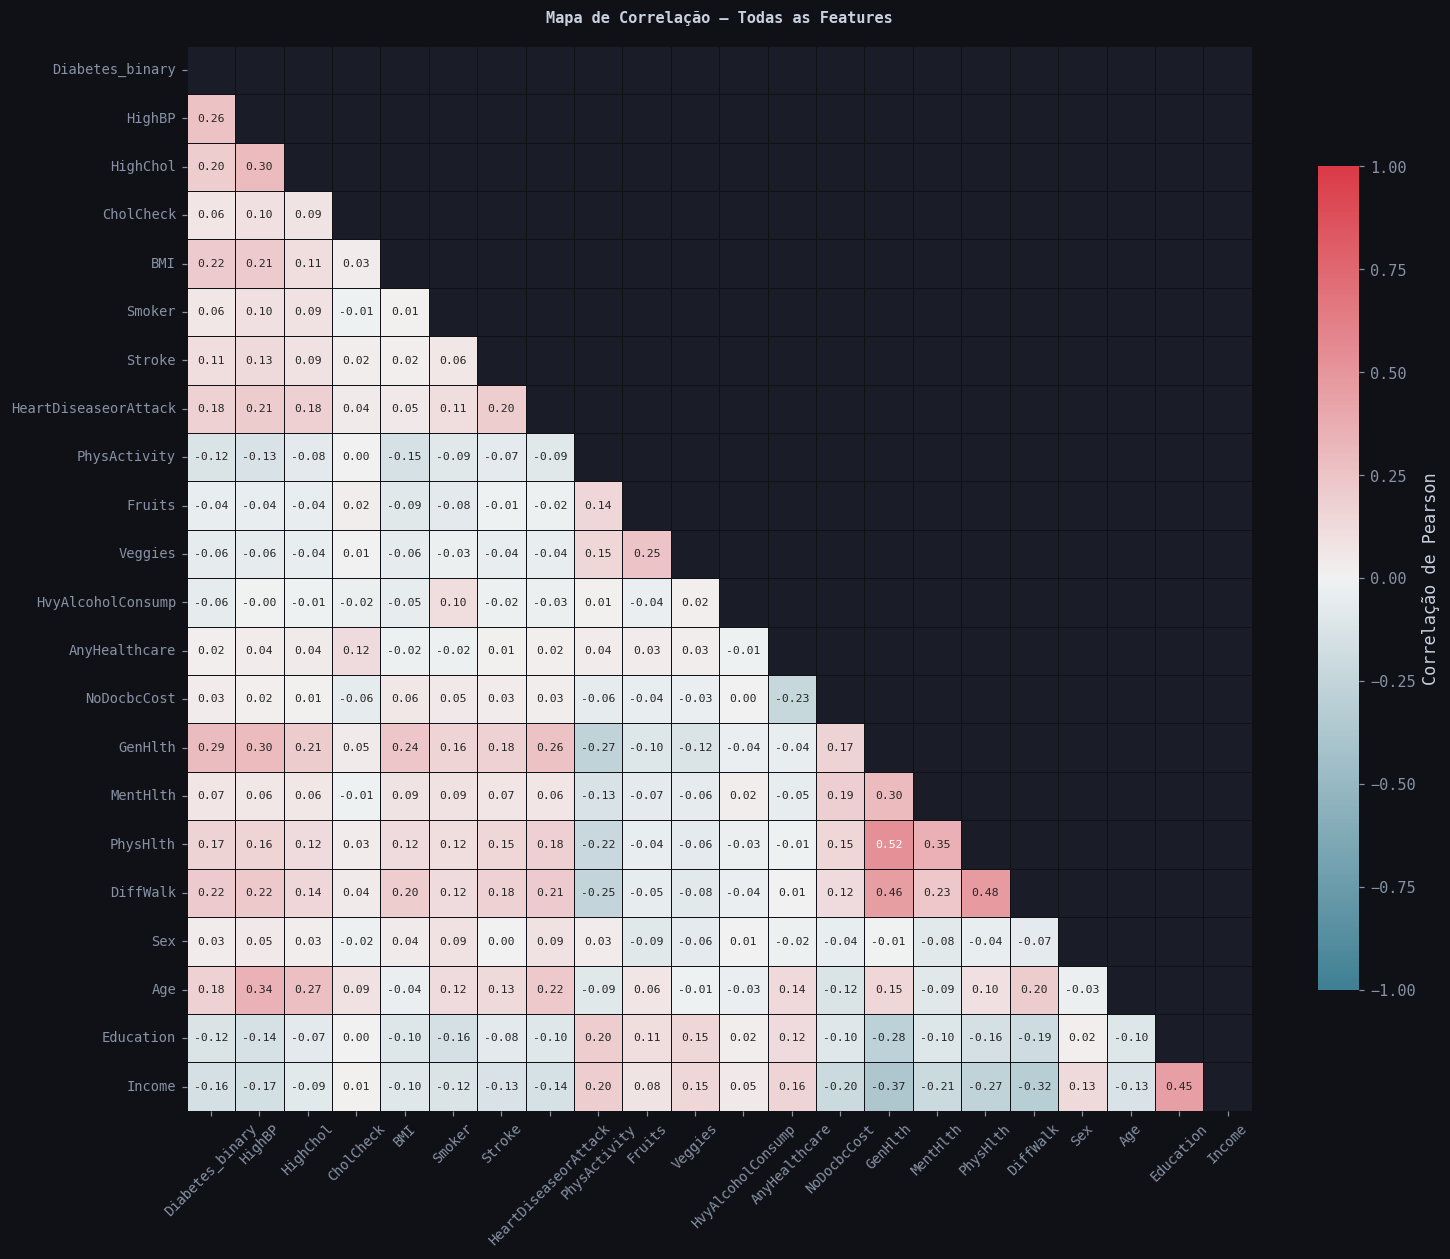


⚠️  Pares com alta correlação entre features (|r| > 0.5):
Feature A Feature B  Correlação
 PhysHlth   GenHlth       0.524


In [ ]:
# Mapa de correlação entre todas as features
fig, ax = plt.subplots(figsize=(14, 12))
corr_full = df.corr()
mask = np.triu(np.ones_like(corr_full, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr_full, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.4,
            linecolor='#0f1117', ax=ax,
            cbar_kws={'shrink': 0.7, 'label': 'Correlação de Pearson'},
            annot_kws={'size': 7.5})

ax.set_title('Mapa de Correlação — Todas as Features',
             fontsize=10, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

# Pares com multicolinearidade alta (|r| > 0.5)
upper = corr_full.where(mask == False)
alta_corr = []
for col in upper.columns:
    for idx in upper.index:
        v = upper.loc[idx, col]
        if pd.notna(v) and abs(v) > 0.5 and col != 'Diabetes_binary' and idx != 'Diabetes_binary':
            alta_corr.append({'Feature A': idx, 'Feature B': col, 'Correlação': round(v, 3)})

if alta_corr:
    print('\n⚠️  Pares com alta correlação entre features (|r| > 0.5):')
    print(pd.DataFrame(alta_corr).sort_values('Correlação', key=abs, ascending=False).to_string(index=False))
else:
    print('\n✅ Nenhum par de features com |r| > 0.5 (baixa multicolinearidade).')

A análise identificou baixa multicolinearidade no dataset, com apenas um par acima de 0,5: PhysHlth e GenHlth (r = 0,524).
Essa correlação é clinicamente plausível, pois ambas refletem aspectos relacionados à saúde geral.
O nível é moderado e não compromete a modelagem.
Modelos de árvore (Random Forest, XGBoost) lidam bem com esse cenário.
Na Regressão Logística, a regularização L2 mitiga possíveis efeitos.
Assim, não há necessidade de remoção de variáveis.

## Análises Aprofundadas de Fatores de Risco

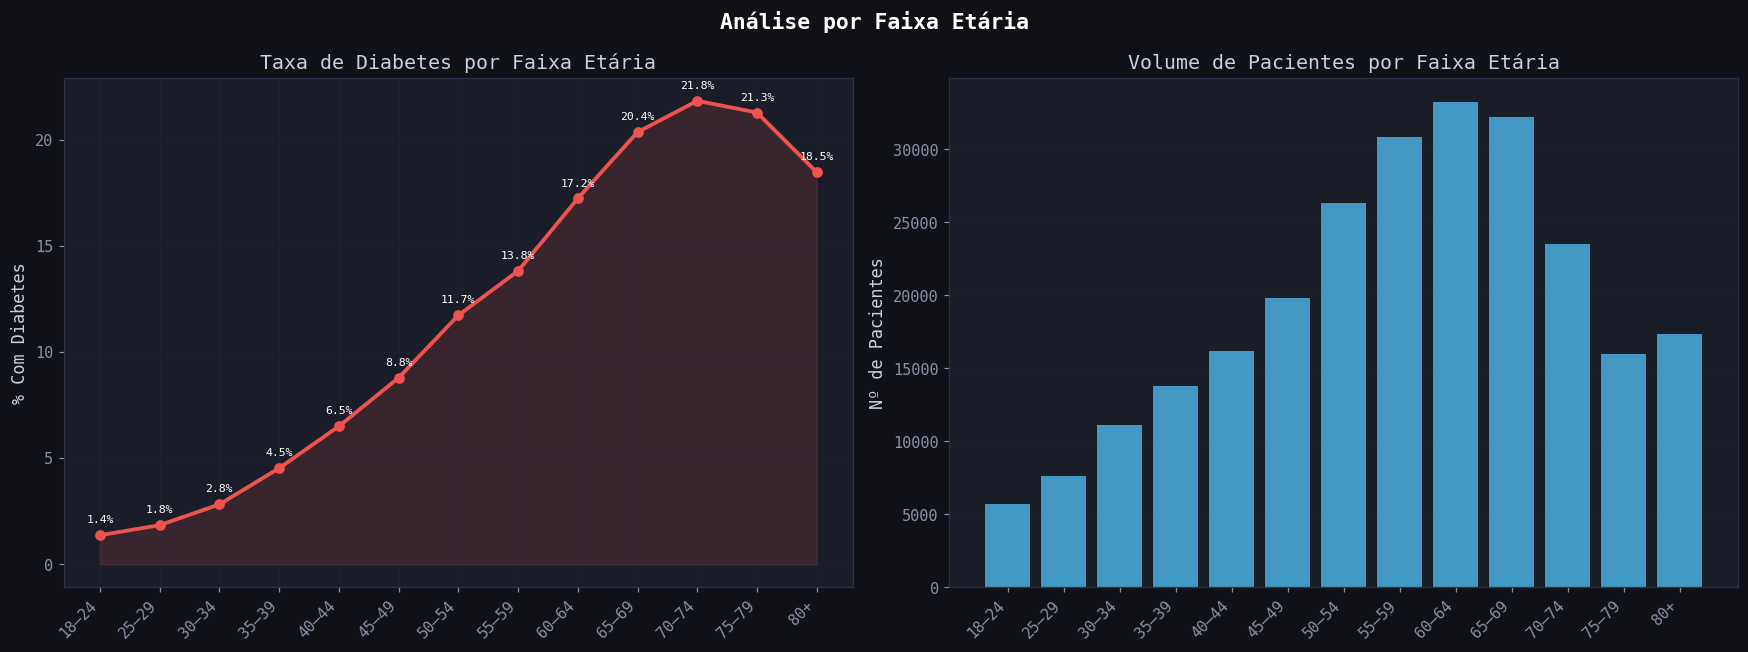

In [ ]:
# Taxa de diabetes por faixa etária
FAIXAS_ETARIAS = {
    1:'18–24', 2:'25–29', 3:'30–34', 4:'35–39', 5:'40–44',
    6:'45–49', 7:'50–54', 8:'55–59', 9:'60–64', 10:'65–69',
    11:'70–74', 12:'75–79', 13:'80+'
}

taxa_idade = df.groupby('Age')['Diabetes_binary'].mean() * 100
contagem_idade = df['Age'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análise por Faixa Etária', fontsize=14, fontweight='bold', color='white')

# Taxa de DM por idade
axes[0].plot(taxa_idade.index, taxa_idade.values, color=CORES[1],
             marker='o', linewidth=2.5, markersize=6)
axes[0].fill_between(taxa_idade.index, taxa_idade.values, alpha=0.15, color=CORES[1])
axes[0].set_xticks(list(FAIXAS_ETARIAS.keys()))
axes[0].set_xticklabels(list(FAIXAS_ETARIAS.values()), rotation=45, ha='right')
axes[0].set_ylabel('% Com Diabetes')
axes[0].set_title('Taxa de Diabetes por Faixa Etária')
axes[0].grid(True, alpha=0.25)
for x, y in zip(taxa_idade.index, taxa_idade.values):
    axes[0].annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=7.5, color='white')

# Distribuição de pacientes por idade
axes[1].bar(contagem_idade.index, contagem_idade.values,
            color=ACCENT, alpha=0.75, edgecolor='none')
axes[1].set_xticks(list(FAIXAS_ETARIAS.keys()))
axes[1].set_xticklabels(list(FAIXAS_ETARIAS.values()), rotation=45, ha='right')
axes[1].set_ylabel('Nº de Pacientes')
axes[1].set_title('Volume de Pacientes por Faixa Etária')
axes[1].grid(axis='y', alpha=0.25)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

A taxa de diabetes cresce quase linearmente com a idade, de 1,4% (18–24) para 21,3% (75–79), aumento de ~15x.
A queda após 80 anos sugere viés de sobrevivência, não proteção real.
A amostra concentra-se entre 50–69 anos, faixa onde o risco já é elevado (>17%).
Isso favorece o treinamento do modelo nas idades de maior incidência.
Age se destaca não só como variável correlacionada, mas como moderadora de risco.
Ela influencia e interage com diversas outras features do dataset.

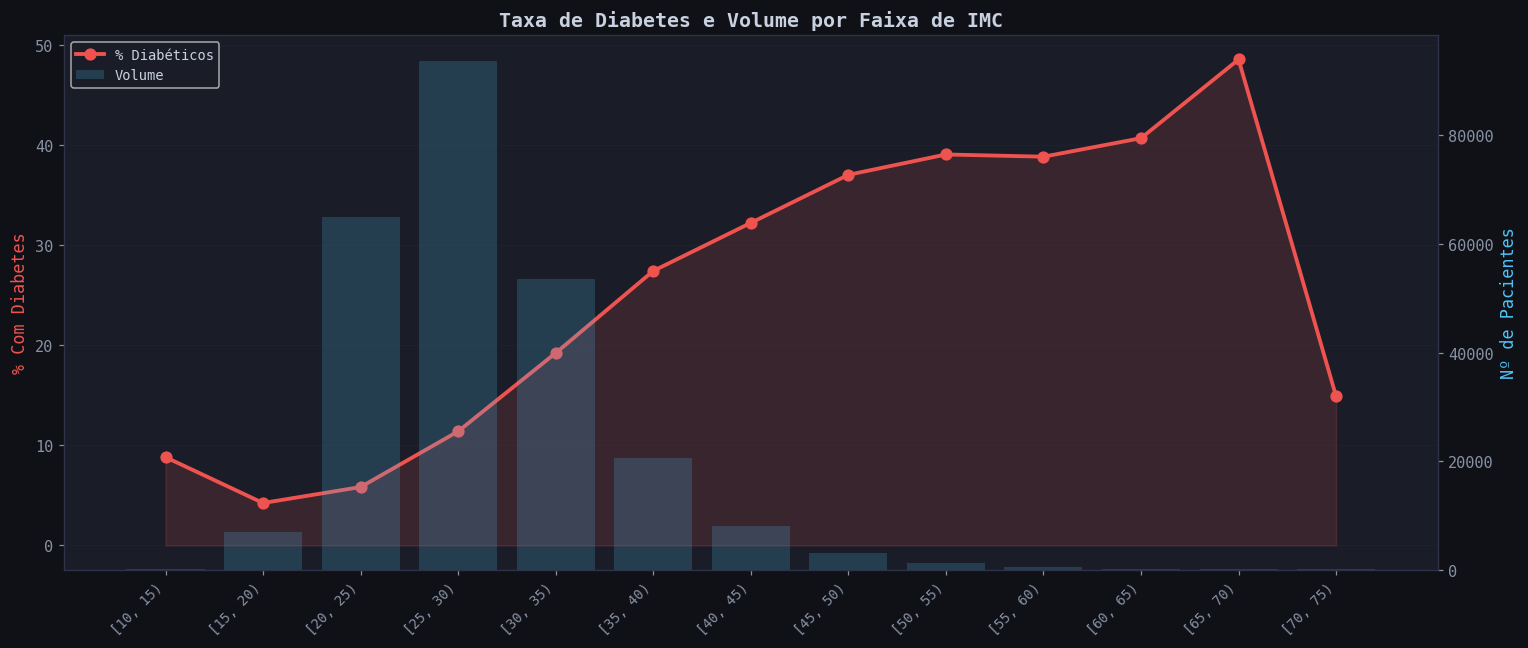

In [ ]:
# Taxa de diabetes por IMC (bins de 5 unidades)
df['IMC_bin'] = pd.cut(df['BMI'], bins=range(10, 80, 5), right=False)
taxa_imc = df.groupby('IMC_bin', observed=True)['Diabetes_binary'].mean() * 100
vol_imc  = df.groupby('IMC_bin', observed=True)['Diabetes_binary'].count()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

x = range(len(taxa_imc))
labels = [str(b) for b in taxa_imc.index]

ax2.bar(x, vol_imc.values, color=ACCENT, alpha=0.2, edgecolor='none', label='Volume')
ax1.plot(x, taxa_imc.values, color=CORES[1], marker='o', linewidth=2.5,
         markersize=7, label='% Diabéticos', zorder=5)
ax1.fill_between(x, taxa_imc.values, alpha=0.15, color=CORES[1])

ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('% Com Diabetes', color=CORES[1])
ax2.set_ylabel('Nº de Pacientes', color=ACCENT)
ax1.set_title('Taxa de Diabetes e Volume por Faixa de IMC',
              fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.25)
ax1.set_axisbelow(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

df.drop(columns='IMC_bin', inplace=True)
plt.tight_layout()
plt.show()

A análise de IMC mostra relação dose-resposta clara: quanto maior o IMC, maior a taxa de diabetes.
O risco sai de <10% em faixas normais e chega a ~47% em obesidade severa.
Quedas acima de IMC 70 são pouco confiáveis devido ao baixo volume (outliers).
O ponto crítico ocorre em IMC ≥30, onde há salto relevante no risco.
Isso valida o limiar clínico de obesidade como marcador preditivo.
Sugere-se criar categorias de IMC para capturar melhor a não-linearidade.

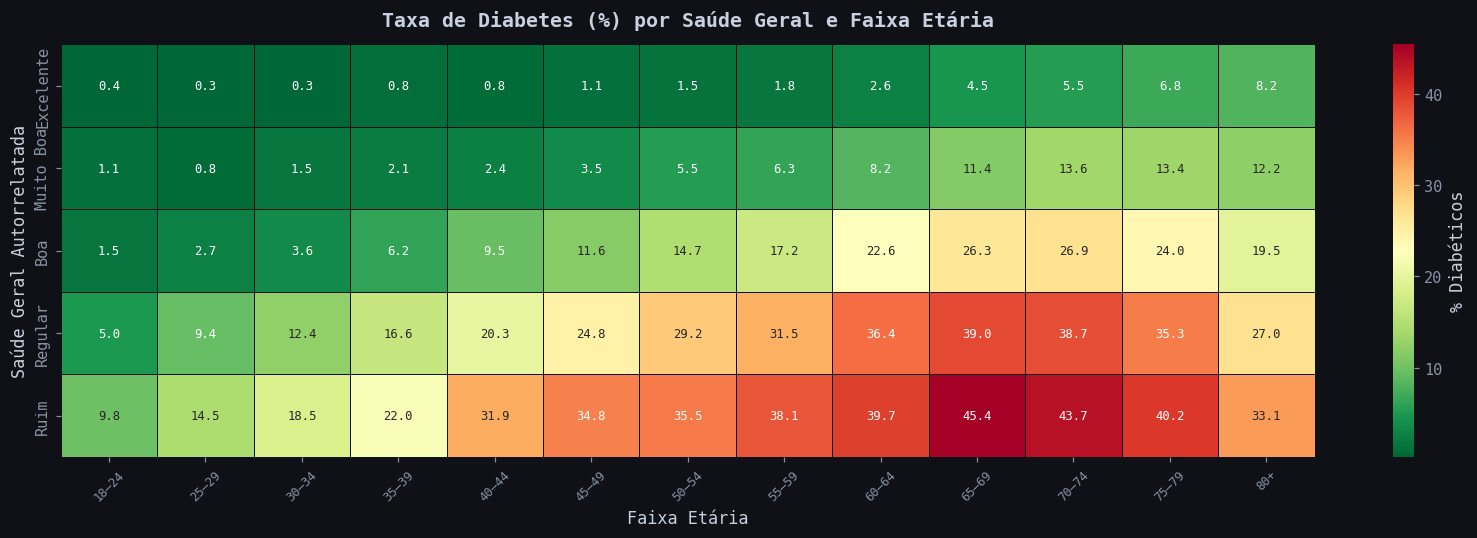

In [ ]:
# Heatmap: Taxa de DM por Idade × Saúde Geral
pivot = df.pivot_table(values='Diabetes_binary', index='GenHlth',
                       columns='Age', aggfunc='mean') * 100

GENHLTH_LABELS = {1:'Excelente', 2:'Muito Boa', 3:'Boa', 4:'Regular', 5:'Ruim'}
pivot.index = [GENHLTH_LABELS[i] for i in pivot.index]
pivot.columns = [FAIXAS_ETARIAS[c] for c in pivot.columns if c in FAIXAS_ETARIAS]

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, linecolor='#0f1117', cbar_kws={'label': '% Diabéticos'},
            annot_kws={'size': 8})
ax.set_title('Taxa de Diabetes (%) por Saúde Geral e Faixa Etária',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('Saúde Geral Autorrelatada')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

O heatmap evidencia o forte efeito combinado de Age e GenHlth no risco de diabetes.
A idade aumenta consistentemente o risco em todos os níveis de saúde.
Já a saúde autorrelatada tem impacto ainda mais intenso dentro de cada faixa etária.
Casos extremos vão de 0,4% (jovens com saúde excelente) a 45,4% (65–69 com saúde ruim).
Mesmo com saúde “muito boa”, idosos apresentam risco elevado (>13%).
Isso mostra que idade e saúde interagem fortemente como fatores de risco.
Sugere-se criar uma feature combinada Age × GenHlth no feature engineering.

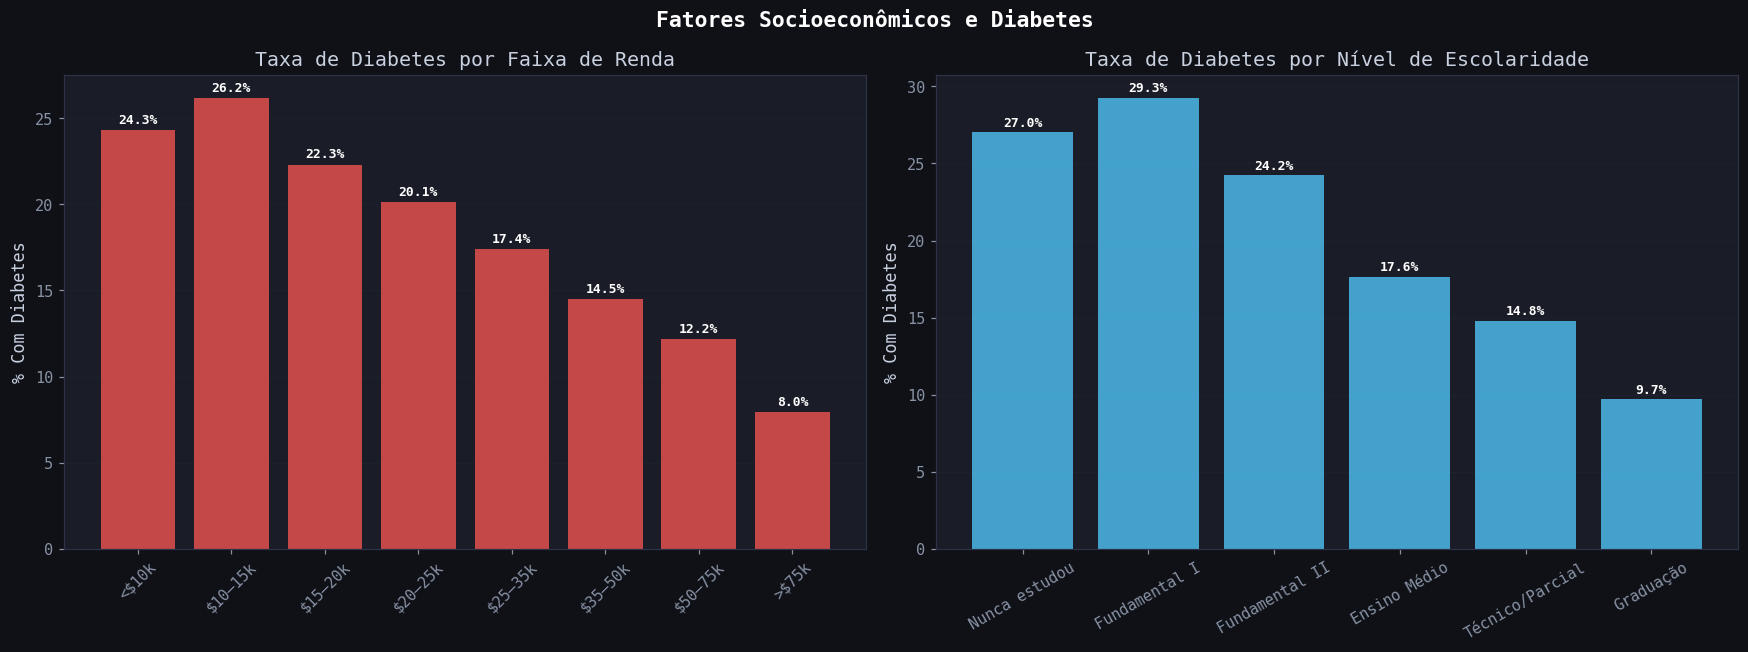

In [ ]:
# Taxa de DM por Renda e Escolaridade
RENDA_LABELS = {
    1:'<$10k', 2:'$10–15k', 3:'$15–20k', 4:'$20–25k',
    5:'$25–35k', 6:'$35–50k', 7:'$50–75k', 8:'>$75k'
}
EDU_LABELS = {
    1:'Nunca estudou', 2:'Fundamental I', 3:'Fundamental II',
    4:'Ensino Médio', 5:'Técnico/Parcial', 6:'Graduação'
}

taxa_renda = df.groupby('Income')['Diabetes_binary'].mean() * 100
taxa_edu   = df.groupby('Education')['Diabetes_binary'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Fatores Socioeconômicos e Diabetes', fontsize=14,
             fontweight='bold', color='white')

# Renda
bars = axes[0].bar([RENDA_LABELS[i] for i in taxa_renda.index],
                   taxa_renda.values, color=CORES[1], alpha=0.8, edgecolor='none')
for bar, v in zip(bars, taxa_renda.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5,
                 fontweight='bold', color='white')
axes[0].set_title('Taxa de Diabetes por Faixa de Renda')
axes[0].set_ylabel('% Com Diabetes')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.25)
axes[0].set_axisbelow(True)

# Escolaridade
bars = axes[1].bar([EDU_LABELS[i] for i in taxa_edu.index],
                   taxa_edu.values, color=ACCENT, alpha=0.8, edgecolor='none')
for bar, v in zip(bars, taxa_edu.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5,
                 fontweight='bold', color='white')
axes[1].set_title('Taxa de Diabetes por Nível de Escolaridade')
axes[1].set_ylabel('% Com Diabetes')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.25)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()

Os dados mostram padrão claro: menor renda e escolaridade estão associadas a maior prevalência de diabetes.
A taxa cai de ~24–26% (<$15k) para 8% (>$75k), redução de ~3x.
Na educação, vai de ~27–29% (baixa escolaridade) para 9,7% (graduação).
Essas variáveis refletem determinantes sociais de saúde (acesso, hábitos e prevenção).
Apesar de correlações moderadas, o efeito é gradual e cumulativo.
Modelos de árvore tendem a capturar melhor essa não-linearidade que modelos lineares.

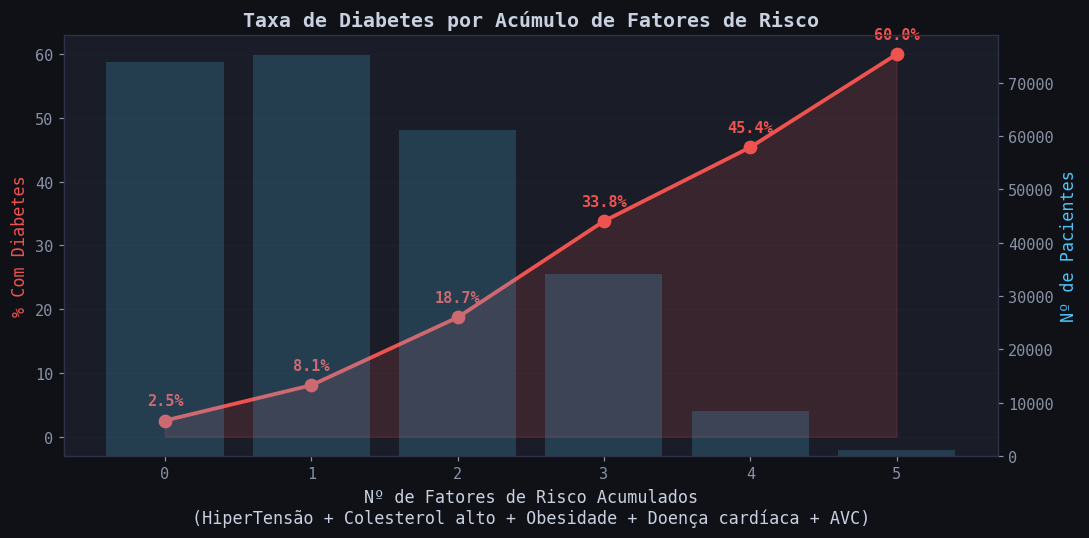

In [ ]:
# Combinações de fatores de risco: HipertensSão + Colesterol + IMC
df['n_riscos'] = (df['HighBP'] + df['HighChol'] + (df['BMI'] >= 30).astype(int) +
                  df['HeartDiseaseorAttack'] + df['Stroke']).astype(int)

taxa_riscos = df.groupby('n_riscos')['Diabetes_binary'].agg(['mean','count'])
taxa_riscos['mean'] *= 100

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax2.bar(taxa_riscos.index, taxa_riscos['count'],
        color=ACCENT, alpha=0.2, edgecolor='none', label='Volume')
ax1.plot(taxa_riscos.index, taxa_riscos['mean'], color=CORES[1],
         marker='o', linewidth=2.5, markersize=8, zorder=5)
ax1.fill_between(taxa_riscos.index, taxa_riscos['mean'], alpha=0.15, color=CORES[1])

for x, y in zip(taxa_riscos.index, taxa_riscos['mean']):
    ax1.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=10,
                 fontweight='bold', color=CORES[1])

ax1.set_xlabel('Nº de Fatores de Risco Acumulados\n(HiperTensão + Colesterol alto + Obesidade + Doença cardíaca + AVC)')
ax1.set_ylabel('% Com Diabetes', color=CORES[1])
ax2.set_ylabel('Nº de Pacientes', color=ACCENT)
ax1.set_title('Taxa de Diabetes por Acúmulo de Fatores de Risco',
              fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.25)
ax1.set_axisbelow(True)

df.drop(columns='n_riscos', inplace=True)
plt.tight_layout()
plt.show()

O gráfico evidencia claramente o risco cumulativo: quanto mais fatores, maior a taxa de diabetes.
A prevalência sobe de 2,5% (nenhum fator) para 60% (cinco fatores) aumento de 24x.
O crescimento é progressivo e quase linear, reforçando o efeito combinado das condições.
A maioria dos pacientes está nos grupos com 1–2 fatores, enquanto extremos são raros.
Isso exige atenção no balanceamento para aprender padrões de alto risco.
O padrão valida a importância clínica da comorbidade acumulada.
Sugere-se criar uma feature de contagem de fatores de risco no modelo.